# Dataset 6 — Credit Approval (UCI)

## Descripción general
Este dataset contiene información sobre solicitudes de tarjetas de crédito. Para proteger la privacidad de los clientes, todos los nombres de las variables y sus valores han sido anonimizados (etiquetas de A1 a A16). Es un dataset clásico que presenta una mezcla de atributos continuos, nominales y una cantidad considerable de valores faltantes.

## Objetivo
**Problema de Clasificación Binaria** — Predecir si una solicitud de crédito será aprobada (`A16 = 1`) o rechazada (`A16 = 0`) en función de los antecedentes del solicitante.

## Tratamiento aplicado

### 1. Manejo de Datos Anónimos y Nulos
Se identificó el carácter `'?'` como marcador de valores faltantes. 
- La columna **A2** (edad aproximada) se forzó a tipo numérico para corregir errores de lectura.
- Los nulos se imputaron con la **mediana** para variables numéricas y la **moda** para las categóricas anónimas.

### 2. Eliminación de Columnas de baja relevancia
Se eliminó la columna **A14** (ZipCode/Código Postal). En este contexto de anonimización, los códigos postales suelen introducir una fragmentación excesiva (alta cardinalidad) que no aporta patrones generalizables al algoritmo de aprendizaje.

### 3. Codificación
- La variable objetivo se transformó de símbolos (`+`, `-`) a valores binarios ($1$, $0$).
- Las variables categóricas anónimas se procesaron mediante **One-Hot Encoding**, permitiendo al modelo trabajar con las diferentes etiquetas de texto como variables independientes.

### 4. Balanceo de Clases (Undersampling)
Originalmente, había más casos rechazados que aprobados. Se aplicó **Undersampling aleatorio** para obtener una proporción de **50/50**, asegurando que el modelo aprenda por igual las características de un buen cliente y de uno riesgoso.

### 5. Preparación Matemática
- División de datos en **80% entrenamiento** y **20% prueba**.
- **Normalización Z-score** aplicada sobre todas las características para asegurar la convergencia del Descenso de Gradiente.
- Inclusión de la **columna de sesgo (unos)** para el cálculo de $\theta_0$.

## ¿Está balanceado?
**Sí.** Mediante el balanceo de clases, se garantizó que el dataset tenga una representación equitativa de ambas etiquetas. En un entorno financiero, esto es vital para evitar sesgos que podrían rechazar injustamente créditos a perfiles válidos o viceversa.

Shape original: (690, 16)

Variable objetivo - A16 (Distribución original):
A16
-    383
+    307
Name: count, dtype: int64

Shape después de eliminar A14 (ZipCode): (690, 15)

Ninguna columna superó el 50% de nulos.
NaN restantes: 0
Shape después de one-hot encoding: (690, 46)

Balanceando las clases (Undersampling)...
Distribución después del balanceo:
A16
1    307
0    307
Name: count, dtype: int64

 DESCRIPCIÓN DEL DATASET PREPARADO
Nombre: Credit Approval (UCI)
Problema: Clasificación Binaria — Aprobación de crédito
Filas listas: 614
Columnas totales: 46

Dataset guardado como 'Credit_preparado.csv'

 INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN
Tamaño X_train_norm: (491, 46)
Tamaño X_test_norm:  (123, 46)


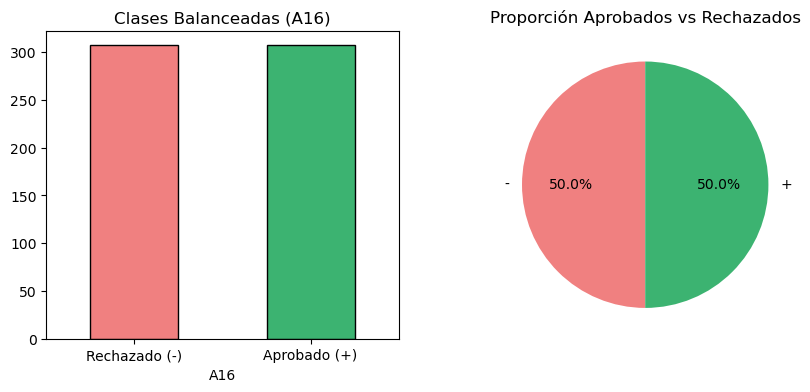

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREPARACIÓN DATASET 6: Credit Approval (Clasificación)


# 1. CARGAR
ruta_credit = r"C:\Users\Usuario\Documents\7mo semestre\Sis420\PrimerParcial\Dataset6\credit+approval\crx.data"

# Nombres de columnas anónimas A1-A16
columnas = [f'A{i}' for i in range(1, 17)]

# Cargamos indicando que '?' es un valor nulo real
df = pd.read_csv(ruta_credit, names=columnas, na_values='?', skipinitialspace=True)

print("Shape original:", df.shape)
print("\nVariable objetivo - A16 (Distribución original):")
print(df['A16'].value_counts())

# 2. ELIMINAR COLUMNAS INÚTILES
# A14 es el ZipCode, no suele aportar valor predictivo en este dataset anónimo
df = df.drop(columns=['A14'])
print("\nShape después de eliminar A14 (ZipCode):", df.shape)

# 3. ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
if cols_muchos_nulos:
    df = df.drop(columns=cols_muchos_nulos)
    print(f"\nColumnas eliminadas por tener >50% de NaN: {cols_muchos_nulos}")
else:
    print("\nNinguna columna superó el 50% de nulos.")

# 4. IMPUTAR NaN RESTANTES
# Aseguramos que A2 sea numérica
df['A2'] = pd.to_numeric(df['A2'], errors='coerce')

cols_numericas = df.select_dtypes(include=['int64', 'float64']).columns
for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cols_texto = df.select_dtypes(include='object').columns
for col in cols_texto:
    if col == 'A16': continue 
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("NaN restantes:", df.isnull().sum().sum())

# 5. ONE-HOT ENCODING
# Convertimos la meta a 0 y 1 (+ es 1, - es 0)
df['A16'] = df['A16'].map({'+': 1, '-': 0})

# Aplicamos One-Hot Encoding a las variables categóricas
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.tolist())
print("Shape después de one-hot encoding:", df.shape)

# 6. BALANCEAR CLASES (Undersampling)
print("\nBalanceando las clases (Undersampling)...")
clase_mayoritaria = df[df['A16'] == 0] # Rechazados (-) suelen ser más
clase_minoritaria = df[df['A16'] == 1] # Aprobados (+)

clase_mayoritaria_reducida = clase_mayoritaria.sample(n=len(clase_minoritaria), random_state=42)
df = pd.concat([clase_mayoritaria_reducida, clase_minoritaria])

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Distribución después del balanceo:")
print(df['A16'].value_counts())

# 7. MOVER TARGET AL FINAL
cols = [c for c in df.columns if c != 'A16'] + ['A16']
df = df[cols]

# 8. RESUMEN FINAL
print("\n DESCRIPCIÓN DEL DATASET PREPARADO")
print(f"Nombre: Credit Approval (UCI)")
print(f"Problema: Clasificación Binaria — Aprobación de crédito")
print(f"Filas listas: {df.shape[0]}")
print(f"Columnas totales: {df.shape[1]}")

# 9. GUARDAR
df.to_csv('Credit_preparado.csv', index=False)
print("\nDataset guardado como 'Credit_preparado.csv'")

# =========================================================
# 10. DIVISIÓN 80/20 Y NORMALIZACIÓN MATEMÁTICA
# =========================================================
print("\n INICIANDO DIVISIÓN 80/20 Y NORMALIZACIÓN")

X = df.drop('A16', axis=1).astype(float).values
y = df['A16'].values

m = len(y)
limite = int(m * 0.8)

X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

def normalizar(X_data):
    mu = np.mean(X_data, axis=0)
    sigma = np.std(X_data, axis=0)
    sigma[sigma == 0] = 1 
    return (X_data - mu) / sigma, mu, sigma

X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Tamaño X_train_norm: {X_train_norm.shape}")
print(f"Tamaño X_test_norm:  {X_test_norm.shape}")

# 11. GRÁFICAS
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['A16'].value_counts().plot(kind='bar', color=['lightcoral', 'mediumseagreen'], edgecolor='black')
plt.title("Clases Balanceadas (A16)")
plt.xticks([0, 1], ['Rechazado (-)', 'Aprobado (+)'], rotation=0)

plt.subplot(1, 2, 2)
plt.pie(df['A16'].value_counts(), labels=['-', '+'], autopct='%1.1f%%', colors=['lightcoral', 'mediumseagreen'], startangle=90)
plt.title("Proporción Aprobados vs Rechazados")
plt.show()